# Fast Topographic Wetness Index (TWI) — End‑to‑End Test

This notebook:
1. **Downloads** a DEM from **OpenTopography** (SRTMGL1_E, ~30 m) for a small UK bounding box (Lake District).
2. **Computes TWI** using a lightweight NumPy/Numba implementation.
3. **Writes** outputs (GeoTIFF) and shows quicklook plots.

> If you're offline, run this later with internet access. Edit the `BBOX` cell to change location/extent.

In [1]:
import rasterio
import numpy as np
from sdm.data.terrain.stats import twi_from_array

## Compute TWI

In [ ]:
OUT_TWI = "data/twi.tif"

with rasterio.open("data/evs/dtm_100m.tif") as src:
    dem = src.read(1).astype(np.float32)
    nodata = src.nodata if src.nodata is not None else np.nan
    cellsize = float(abs(src.transform.a))
    print("DEM shape:", dem.shape, "cellsize:", cellsize, "nodata:", nodata)

twi = twi_from_array(
    dem if np.isnan(nodata) else np.where(dem == nodata, np.nan, dem),
    cellsize=cellsize,
    slope_eps=1e-2,
    flats_tol=0,
)

# Write TWI GeoTIFF (copy georeferencing)
with rasterio.open("data/evs/dtm_100m.tif") as src:
    profile = src.profile
profile.update(dtype="float32", count=1, nodata=np.nan, compress="LZW")
with rasterio.open(OUT_TWI, "w", **profile) as dst:
    dst.write(twi.astype("float32"), 1)

print("Wrote", OUT_TWI)

DEM shape: (1639, 2048) cellsize: 100.0 nodata: nan
Wrote data/twi.tif


## Quicklook plots

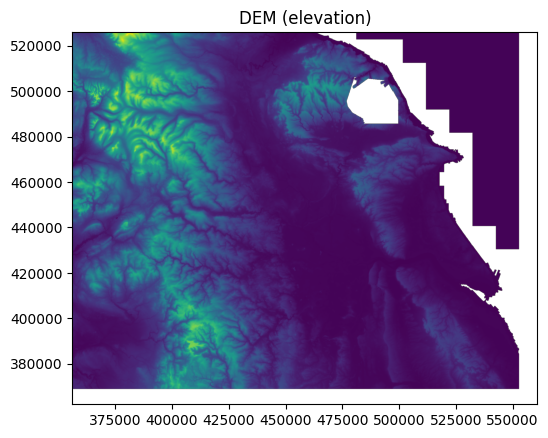

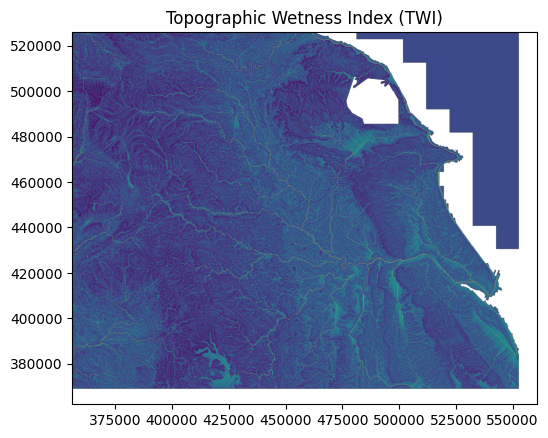

In [12]:
from matplotlib import pyplot as plt
import os
import math
import requests
import numpy as np
import rasterio
from rasterio.transform import Affine
from rasterio.plot import show
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
with rasterio.open("data/evs/dtm_100m.tif") as src:
    show(src.read(1), ax=ax, transform=src.transform)
ax.set_title("DEM (elevation)")
plt.show()


fig, ax = plt.subplots(figsize=(6, 5))
with rasterio.open("data/twi.tif") as src:
    show(src.read(1), ax=ax, transform=src.transform)
ax.set_title("Topographic Wetness Index (TWI)")
plt.show()

## Basic stats

TWI stats — min/max/mean: 5.048346042633057 32.862449645996094 11.15612506866455
Valid pixels: 2888981


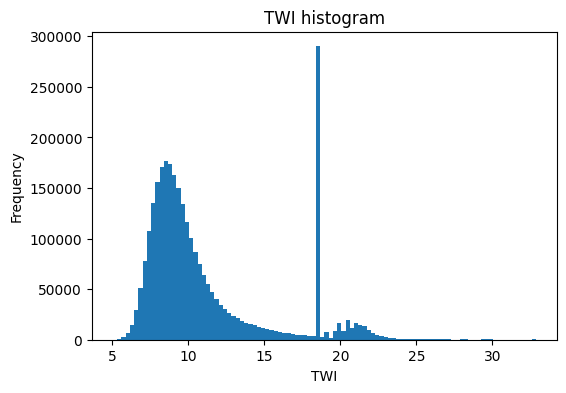

In [4]:
arr = rasterio.open("data/twi.tif").read(1)
finite = np.isfinite(arr)
print(
    "TWI stats — min/max/mean:",
    float(np.nanmin(arr)),
    float(np.nanmax(arr)),
    float(np.nanmean(arr)),
)
print("Valid pixels:", int(finite.sum()))

# Histogram
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(arr[finite].ravel(), bins=100)
ax.set_title("TWI histogram")
ax.set_xlabel("TWI")
ax.set_ylabel("Frequency")
plt.show()